In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.8 MB/s eta 0:00:00


In [38]:
import numpy as np
from numpy import pi
import random
from functools import partial
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.linalg import eigh, sqrtm
from scipy.special import erf
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit import Parameter
from qiskit.circuit.classical import expr
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator, random_statevector, process_fidelity
from qiskit.circuit.library import QAOAAnsatz, hamiltonian_variational_ansatz, XXPlusYYGate, CPhaseGate, UnitaryGate, U3Gate, CXGate,PauliEvolutionGate, PauliGate
from qiskit.synthesis import TwoQubitBasisDecomposer
from qiskit.synthesis.evolution import SuzukiTrotter
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler, EstimatorV2 as Estimator,QiskitRuntimeService
from qiskit_ibm_runtime.options import EnvironmentOptions, EstimatorOptions,SamplerOptions
from qiskit_aer.noise import NoiseModel, ReadoutError

## Noise


In [3]:
def P1(qc, q, p1):

    r = np.random.rand()
    if r >= p1:
        return qc
    gate = PauliGate(np.random.choice(['X', 'Y', 'Z']))
    qc.append(gate, [q])

    return qc

In [4]:
def P2(qc, q0, q1, p2):

    r = np.random.rand()

    if r >= p2:
        return qc

    gate1 = PauliGate(np.random.choice(['X', 'Y', 'Z']))
    gate2 = PauliGate(np.random.choice(['X', 'Y', 'Z']))

    qc.append(gate1, [q0])
    qc.append(gate2, [q1])

    return qc

In [5]:
def idle(N, qc, p1, q0, q1=None, q2=None):

    active = {q0}

    if q1 is not None:
        active.add(q1)

    if q2 is not None:
        active.add(q2)

    for q in range(2 * N):

        if q not in active:
            P1(qc, q, p1)

    return qc

## Measurement


In [6]:
def measure_ZZ(qc, N, q0, q1, cbit, p1, p2):

    idle(N, qc, p1, q0, q1)

    P2(qc, q0, q1, p2/2)
    P1(qc, q0, p1/2)
    P1(qc, q1, p1/2)

    qc.cx(q0, q1)
    qc.measure(q1, cbit)
    qc.cx(q0, q1)

    P2(qc, q0, q1, p2/2)
    P1(qc, q0, p1/2)
    P1(qc, q1, p1/2)

In [7]:
def measure_XI(qc, N, q0, q1, cbit, p1, p2):

    idle(N, qc, p1, q0)

    P1(qc, q0, p1/2)

    qc.h(q0)
    qc.measure(q0, cbit)
    qc.h(q0)

    P1(qc, q0, p1/2)

**Important: fix convention $ Y = S X S^\dagger$. Later formulas must use the same convention to ensure a correct pauli tracking**

In [8]:
def measure_YI(qc, N, q0, q1, cbit, p1, p2):
    qc.sdg(q0)
    measure_XI(qc, N, q0, q1, cbit, p1, p2)
    qc.s(q0)

In [9]:
def measure_ZY(qc, N, q0, q1, cbit, p1, p2):

    # with the same convention, Y = S X S^d = S H Z H S^d
    qc.sdg(q1)
    qc.h(q1)
    measure_ZZ(qc, N, q0, q1, cbit, p1, p2)
    qc.h(q1)
    qc.s(q1)

In [10]:
def measure_ZX(qc, N, q0, q1, cbit, p1, p2):

    qc.h(q1)
    measure_ZZ(qc, N, q0, q1, cbit, p1, p2)
    qc.h(q1)

## Single qubit clifford group

In [11]:
def add_H(qc, N, d, a, cbit, p1, p2):
    c = cbit

    measure_XI(qc, N, a, d, c[0], p1, p2)
    measure_ZY(qc, N, a, d, c[1], p1, p2)
    measure_YI(qc, N, a, d, c[2], p1, p2)
    measure_XI(qc, N, a, d, c[3], p1, p2)

    parity = expr.bit_xor(expr.bit_xor(c[0], c[1]), c[2])
    with qc.if_test(expr.logic_not(parity)):
        qc.y(d)

    qc.x(d)

    return qc

In [12]:
def add_S(qc, N, d, a, cbit, p1, p2):
    c = cbit

    # (ancilla, data) = (q+1, q)

    measure_XI(qc, N, a, d, c[0], p1, p2)
    measure_ZZ(qc, N, a, d, c[1], p1, p2)
    measure_YI(qc, N, a, d, c[2], p1, p2)
    measure_XI(qc, N, a, d, c[3], p1, p2)

    # measurement bit c_i encodes s_i = (-1)^{c_i}
    # s_i s_j = (-1)^{c[i] + c[j]}
    # product becomes XOR

    # Z^{(1 + s0 s1 s2)/2}
    # exponent = 1 when s0 s1 s2 = +1
    # s0 s1 s2 = (-1)^{c0 + c1 + c2}
    # +1 when (c0 + c1 + c2) mod 2 = 0 (even parity)

    parity = expr.bit_xor(expr.bit_xor(c[0], c[1]), c[2])
    with qc.if_test(expr.logic_not(parity)):
        qc.z(d)

    return qc

In [13]:
def add_HSH(qc, N, d, a, cbit, p1, p2):
    c = cbit

    measure_XI(qc, N, a, d, c[0], p1, p2)
    measure_ZZ(qc, N, a, d, c[1], p1, p2)
    measure_ZY(qc, N, a, d, c[2], p1, p2)
    measure_XI(qc, N, a, d, c[3], p1, p2)

    # Y^{(1 - s0 s3)/2} odd parity
    parity_03 = expr.bit_xor(c[0], c[3])
    with qc.if_test(parity_03):
        qc.y(d)

    # X^{(1 + s1 s2)/2} even parity
    parity_12 = expr.bit_xor(c[1], c[2])
    with qc.if_test(expr.logic_not(parity_12)):
        qc.x(d)

    return qc

In [14]:
def add_HS(qc, N, d, a, cbit, p1, p2):
    c = cbit

    measure_XI(qc, N, a, d, c[0], p1, p2)  # s0
    measure_ZY(qc, N, a, d, c[1], p1, p2)  # s1
    measure_ZZ(qc, N, a, d, c[2], p1, p2)  # s2
    measure_YI(qc, N, a, d, c[3], p1, p2)  # s3
    measure_XI(qc, N, a, d, c[4], p1, p2)  # s4

    # X^{(1 + s1 s2)/2} even parity
    parity_12 = expr.bit_xor(c[1], c[2])
    with qc.if_test(expr.logic_not(parity_12)):
        qc.x(d)

    # Z^{(1 + s0 s1 s3)/2} even parity
    parity_013 = expr.bit_xor(expr.bit_xor(c[0], c[1]), c[3])
    with qc.if_test(expr.logic_not(parity_013)):
        qc.z(d)

    return qc

In [15]:
def sqrt_W():
    X = np.array([
        [0, 1],
        [1, 0]
    ], dtype=complex)

    Y = np.array([
        [0, -1j],
        [1j, 0]
    ], dtype=complex)

    W = (X + Y) / np.sqrt(2)

    return sqrtm(W)

## Single qubit gate in supremacy circuit

In [16]:
def add_sqrtX(qc, N, d, a, cbit, p1, p2):
    qc = add_HSH(qc, N, d, a, cbit, p1, p2)
    return qc

In [17]:
def add_sqrtY(qc, N, d, a, cbit, p1, p2):
   qc = add_S(qc, N, d, a, cbit, p1, p2)
   qc = add_HS(qc, N, d, a, cbit, p1, p2)
   return qc

In [18]:
def add_sqrtW(qc, N, d, a, cbit, p1, p2):
    qc.tdg(d)
    qc = add_sqrtX(qc, N, d, a, cbit, p1, p2)
    qc.t(d)
    return qc

## Two qubit gate in supremacy circuit

### fSim decomposition

The two-qubit gate fSim(θ, φ) can be decomposed into **3 CNOT gates** and 8 single-qubit layers.


Each 1-qubit untary is decomposed in Euler basis ZSX
$$
U = R_z(\alpha)\, \sqrt{X}\, R_z(\beta)\, \sqrt{X}\, R_z(\gamma)
$$

For angles that are multiples of $\pi/2$, we further simplify:
$$
R_z(k\pi/2) \;\rightarrow\; S^k \quad (\mathrm{mod}\;4)
$$

The gate set we need contains
- $\mathrm{CNOT}$
- $\sqrt{X}$
- $S$
- $R_z$

---
### Circuit structure
$$
(U_0 \otimes U_1)\;\rightarrow\;\mathrm{CNOT}\;\rightarrow\;
(U_2 \otimes U_3)\;\rightarrow\;\mathrm{CNOT}\;\rightarrow\;
(U_4 \otimes U_5)\;\rightarrow\;\mathrm{CNOT}\;\rightarrow\;
(U_6 \otimes U_7)
$$


---
Note: we need at **8 classical bits** to implement supremacy circuits with two-qubit gates.

To measure bitstring distribution in the end, add N extra classical bits.

Examples of fSim decomposation is shown at the end of this section

In [19]:
# fSim matrix

def fSim(theta, phi):
    return np.array([
        [1, 0, 0, 0],
        [0, np.cos(theta), -1j*np.sin(theta), 0],
        [0, -1j*np.sin(theta), np.cos(theta), 0],
        [0, 0, 0, np.exp(-1j*phi)]
    ], dtype=complex)

In [20]:
def add_CNOT(qc, N, c, a, t, cbit, p1, p2):
    # needs 8 cbits. all_ reuses cbit[0-4]. measure_ uses cbit[5-7]
    # Qubit A is initialized in an eigenstate of Z

    # prepare a in z-basis
    qc.reset(a)

    measure_ZX(qc, N, c, a, cbit[5], p1, p2)
    measure_ZX(qc, N, a, t, cbit[6], p1, p2)

    # this is single X-measurement on qubit a. h is on level of simulation, not circuit element
    measure_XI(qc, N, a, c, cbit[7], p1, p2)

    # we use cbit directly because it stores as 0(even) and 1(odd), as needed in paper
    P1 = cbit[5]
    P2 = cbit[6]
    M  = cbit[7]

    # X_t^{(P1 ⊕ M)}
    xt = expr.bit_xor(P1, M)
    with qc.if_test(xt):
        qc.x(t)

    #Z_c^{P2}
    with qc.if_test((P2, 1)):
        qc.z(c)

    return qc

In [21]:
def apply_rz_or_s(qc, qubit, angle):

    # identify z-rotation as clifford gate

    # normalize to [-π, π]
    theta = (angle + np.pi) % (2*np.pi) - np.pi

    # check multiple of π/2
    k = round(theta / (np.pi/2))

    if abs(theta - k*(np.pi/2)) < 1e-3:
        k_mod = k % 4
        for _ in range(k_mod):
            qc.s(qubit)
    else:
        qc.rz(theta, qubit)

    return qc

In [22]:
def get_zsx_blocks_and_cx(theta, phi):

    # decompose fSim into 3 CNOTs and Euler rotations in ZSX basis

    qc = QuantumCircuit(2)
    qc.append(UnitaryGate(fSim(theta, phi)), [0, 1])

    U_target = Operator(qc).data

    decomposer = TwoQubitBasisDecomposer(
        CXGate(),
        euler_basis="ZSX",
    )

    synth = decomposer(U_target)

    synth = transpile(
        synth,
        basis_gates=["rz", "sx", "x", "cx"],
        optimization_level=3,
    )

    blocks = []
    cx_dirs = []
    current = {0: [], 1: []}

    for instr in synth.data:
        inst = instr.operation
        qargs = instr.qubits
        name = inst.name

        if name == "cx":
            blocks.append(current)
            current = {0: [], 1: []}

            ctrl = synth.find_bit(qargs[0]).index
            targ = synth.find_bit(qargs[1]).index
            cx_dirs.append((ctrl, targ))

            continue

        q = synth.find_bit(qargs[0]).index

        if name == "rz":
            current[q].append(("rz", float(inst.params[0])))
        elif name == "sx":
            current[q].append(("sx", None))
        elif name == "x":
            current[q].append(("x", None))

    blocks.append(current)

    return blocks, cx_dirs

In [44]:
def add_TwoQubitGate(qc, N, c, a, t, theta, phi, Z1, Z2, Z3, Z4, cbit, p1, p2):

    # build two qubit gate for supremacy circuit

    idle(N, qc, p1, c)
    qc.rz(Z1, c)
    idle(N, qc, p1, t)
    qc.rz(Z2, t)

    blocks, cx_dirs = get_zsx_blocks_and_cx(theta, phi)

    for layer in range(4):

        block = blocks[layer]

        # ---- 1Q gates ----
        for qubit in [0, 1]:

            target = c if qubit == 0 else t

            for name, angle in block[qubit]:

                if name == "rz":
                    qc = apply_rz_or_s(qc, target, angle)

                elif name == "sx":
                    qc = add_sqrtX(qc, N, target, a, cbit, p1, p2)

                elif name == "x":
                    qc = add_sqrtX(qc, N, target, a, cbit, p1, p2)
                    qc = add_sqrtX(qc, N, target, a, cbit, p1, p2)

        # ---- CX with correct direction ----
        if layer < 3:
            ctrl, targ = cx_dirs[layer]

            if ctrl == 0:
                qc = add_CNOT(qc, N, c, a, t, cbit, p1, p2)
            else:
                qc = add_CNOT(qc, N, t, a, c, cbit, p1, p2)

    idle(N, qc, p1, c)
    qc.rz(Z3, c)
    idle(N, qc, p1, t)
    qc.rz(Z4, t)

    return qc

### Example of fSim decomposation

In [45]:
def fSim_diagram(theta, phi):

    blocks, cx_dirs = get_zsx_blocks_and_cx(theta, phi)

    qc = QuantumCircuit(2)

    for layer in range(4):

        block = blocks[layer]

        for qubit in [0, 1]:

            for name, angle in block[qubit]:

                if name == "rz":
                    qc = apply_rz_or_s(qc, qubit, angle)

                elif name == "sx":
                    qc.sx(qubit)

                elif name == "x":
                    qc.sx(qubit)
                    qc.sx(qubit)

        if layer < 3:
            ctrl, targ = cx_dirs[layer]
            qc.cx(ctrl, targ)

    return qc

In [25]:
theta = 0.53*np.pi
phi   = 0.78*np.pi

qc_target = QuantumCircuit(2)
qc_target.append(UnitaryGate(fSim(theta, phi)), [0, 1])

qc_synth = fSim_diagram(theta, phi)

print("\nSynthesized fSim: theta =", theta, ", phi =", phi)
print()
print(qc_synth.draw())

# fidelity
fid = process_fidelity(Operator(qc_synth), Operator(qc_target))
print("\nProcess fidelity:", fid)

# CX count
cx_count = qc_synth.count_ops().get("cx", 0)
print("CX count:", cx_count)


Synthesized fSim: theta = 1.6650441064025905 , phi = 2.4504422698000385

     ┌───────────┐┌────┐┌───┐┌───┐┌───┐┌────────────┐               ┌───┐»
q_0: ┤ Rz(-3π/4) ├┤ √X ├┤ S ├┤ S ├┤ X ├┤ Rz(1.4765) ├───────────────┤ X ├»
     └┬─────────┬┘├────┤├───┤└───┘└─┬─┘└───┬────┬───┘┌─────────────┐└─┬─┘»
q_1: ─┤ Rz(π/4) ├─┤ √X ├┤ S ├───────■──────┤ √X ├────┤ Rz(-3.0473) ├──■──»
      └─────────┘ └────┘└───┘              └────┘    └─────────────┘     »
«     ┌────────────┐┌───┐┌────┐┌────┐ ┌───────────┐  
«q_0: ┤ Rz(1.2252) ├┤ X ├┤ √X ├┤ √X ├─┤ Rz(1.131) ├──
«     └───┬────┬───┘└─┬─┘├────┤├────┤┌┴───────────┴─┐
«q_1: ────┤ √X ├──────■──┤ √X ├┤ √X ├┤ Rz(-0.43982) ├
«         └────┘         └────┘└────┘└──────────────┘

Process fidelity: 1.0000000000000004
CX count: 3


# MVP circuit

### Simulation setup

**Qubit geometry:**
$$
(i,0)=\text{data}, \qquad (i,1)=\text{ancilla}
$$

The physical qubit index is:
$$
q(i,j)=2i+j.
$$

For each period, we first use the Google's assignment of 1-qubit gates on the data–ancilla pair $(q_0, q_0 + 1)$.  
Then, we randomly assign qubits into data qubit pairs $(q_0, q_1)$, and apply the supremacy 2-qubit gates with random parameters $(Z_1, Z_2, Z_3, Z_4, \theta, \phi)$ on each pair. For each data qubit pair $(q_0, q_1)$, we use the ancilla qubit $q_0 + 1$. In the MVP circuit, we allow long-range connectivity among both data qubits and ancilla qubits.

We test the implementation using a system of $4 \times 2$ qubits over 10 periods.

For each test, we use:
- a random entangled initial state  
- random parameters / random seed  

The verification metric is wavefunction overlap  

In [46]:
def MVP_gate(qc, N, periods, seed):
    rng = np.random.default_rng(seed)

    # Use exactly N qubits
    data_qubits = list(range(N))

    last_gate = [None] * N

    for p in range(periods):

        # =========================
        # 1. Single-qubit layer
        # =========================
        for i in range(N):

            q = data_qubits[i]

            choices = ["sX", "sY", "sW"]

            if last_gate[i] is not None:
                choices.remove(last_gate[i])

            gate = rng.choice(choices)

            if gate == "sX":
                qc.sx(q)

            elif gate == "sY":
                qc.ry(np.pi / 2, q)

            elif gate == "sW":
                qc.append(UnitaryGate(sqrt_W()), [q])

            last_gate[i] = gate

        qc.barrier()

        # =========================
        # 2. Two-qubit layer
        # =========================

        perm = np.arange(N)
        rng.shuffle(perm)

        # Pair as many qubits as possible
        for i in range(0, N, 2):

            q0 = data_qubits[perm[i]]
            q1 = data_qubits[perm[i + 1]]

            Z1, Z2, Z3, Z4, theta, phi = rng.uniform([0, 0, 0, 0, 0, 0], [4*np.pi, 4*np.pi, 4*np.pi, 4*np.pi, np.pi, 2*np.pi])

            qc.rz(Z1, q0)
            qc.rz(Z2, q1)

            qc.append(
                UnitaryGate(fSim(theta, phi)),
                [q0, q1]
            )

            qc.rz(Z3, q0)
            qc.rz(Z4, q1)

        qc.barrier()

    return qc

In [27]:
N = 4
periods = 1
seed = 42

qc = QuantumCircuit(N)

qc = MVP_gate(qc, N, periods, seed)

qc.draw(fold=-1)

┌────┐   ░ ┌────────────┐             ┌──────────┐ ┌────────────┐ ░ 
q_0: ───┤ √X ├───░─┤ Rz(11.646) ├─────────────┤1         ├─┤ Rz(10.339) ├─░─
     ┌──┴────┴─┐ ░ ├───────────┬┘┌──────────┐ │          │ ├───────────┬┘ ░ 
q_1: ┤ Unitary ├─░─┤ Rz(12.26) ├─┤1         ├─┤  Unitary ├─┤ Rz(9.878) ├──░─
     ├─────────┤ ░ ├───────────┴┐│          │ │          │ ├───────────┤  ░ 
q_2: ┤ Ry(π/2) ├─░─┤ Rz(4.6596) ├┤  Unitary ├─┤0         ├─┤ Rz(8.091) ├──░─
     ├─────────┤ ░ ├────────────┤│          │┌┴──────────┴┐└───────────┘  ░ 
q_3: ┤ Ry(π/2) ├─░─┤ Rz(1.1835) ├┤0         ├┤ Rz(9.5648) ├───────────────░─
     └─────────┘ ░ └────────────┘└──────────┘└────────────┘               ░

In [47]:
def MVP_MBQC(qc, N, periods, seed, p1, p2):
    rng = np.random.default_rng(seed)

    # add classical register once
    if not qc.cregs:
        qc.add_register(ClassicalRegister(8))

    cbit = qc.cregs[0]

    data_qubits = [2 * i for i in range(N)]
    last_gate = [None] * N

    for p in range(periods):

        # =========================
        # 1. Single-qubit MBQC layer
        # =========================
        for i in range(N):
            q = data_qubits[i]
            anc = q + 1

            choices = ["sX", "sY", "sW"]
            if last_gate[i] is not None:
                choices.remove(last_gate[i])

            gate = rng.choice(choices)

            if gate == "sX":
                qc = add_sqrtX(qc, N, q, anc, cbit, p1, p2)
            elif gate == "sY":
                qc = add_sqrtY(qc, N, q, anc, cbit, p1, p2)
            else:
                qc = add_sqrtW(qc, N, q, anc, cbit, p1, p2)

            last_gate[i] = gate

        # =========================
        # 2. Two-qubit MBQC layer
        # =========================

        perm = np.arange(N)
        rng.shuffle(perm)

        for i in range(0, N, 2):
            q0 = data_qubits[perm[i]]
            q1 = data_qubits[perm[i + 1]]

            # correct parameter ordering
            Z1, Z2, Z3, Z4, theta, phi = rng.uniform(
                [0, 0, 0, 0, 0, 0],
                [4*np.pi, 4*np.pi, 4*np.pi, 4*np.pi, np.pi, 2*np.pi]
            )

            qc = add_TwoQubitGate(
                qc, N,
                q0, q0 + 1,   # data + ancilla (control side)
                q1,           # target data (ancilla assumed internal if needed)
                theta,
                phi,
                Z1, Z2, Z3, Z4,
                cbit, p1, p2
            )

    return qc

In [48]:
def subsystem_fidelity_with_pure_target(full_mbqc_sv, target_sv, data_qubits):
    """
    Compare an MBQC statevector against a target pure data state.

    Parameters
    ----------
    full_mbqc_sv : Statevector
        Full MBQC statevector including data + ancilla qubits.

    target_sv : Statevector
        Pure target state on the logical/data qubits.

    data_qubits : list[int]
        Indices of the data qubits inside the MBQC register.

        The order must match the qubit ordering of target_sv.

    Returns
    -------
    fidelity : float
        Fidelity between the reduced MBQC data subsystem and target_sv.

            F = <target| rho_data |target>
    """

    full_data = np.asarray(full_mbqc_sv.data)
    target = np.asarray(target_sv.data)

    n_total = int(round(np.log2(full_data.size)))
    n_data = len(data_qubits)

    env_qubits = [q for q in range(n_total) if q not in data_qubits]

    # Qiskit little-endian tensor layout
    tensor = full_data.reshape([2] * n_total, order='F')

    # Put logical/data subsystem first
    tensor = np.transpose(tensor, data_qubits + env_qubits)

    # Matrix:
    # rows   -> logical subsystem basis
    # cols   -> ancilla/environment basis
    psi = tensor.reshape(
        (2**n_data, 2**(n_total - n_data)),
        order='F'
    )

    # overlaps with target state
    overlaps = target.conj() @ psi

    # sum over environment branches
    fidelity = np.sum(np.abs(overlaps)**2)

    return float(np.real_if_close(fidelity))

In [40]:
def get_simulator(N, p_a):

    readout_error = ReadoutError([
        [1 - p_a, p_a],
        [p_a, 1 - p_a]
    ])

    noise_model = NoiseModel()

    for q in range(2 * N):
        noise_model.add_readout_error(readout_error, [q])

    return AerSimulator(method="statevector", noise_model=noise_model)

In [50]:
N = 4
periods = 10
num_trials = 1
tol = 1e-6

p1 = 0.1
p2 = 0.1
p_a = 0.1

sim = get_simulator(N, p_a)

for i in range(num_trials):

    psi = random_statevector(2**N)
    seed = np.random.randint(1000)

    # --- direct circuit ---
    qc1 = QuantumCircuit(N)
    qc1.initialize(psi.data, range(N))
    qc1 = MVP_gate(qc1, N, periods, seed)

    sv1 = Statevector.from_instruction(qc1)

    # --- MBQC circuit ---
    qc2 = QuantumCircuit(2*N)
    qc2.initialize(psi.data, list(range(0, 2*N, 2)))

    qc2 = MVP_MBQC(qc2, N, periods, seed, p1, p2)

    qc2.save_statevector(conditional=True)

    result = sim.run(qc2, shots=1).result()

    data = result.data(0)["statevector"]

    sv_mbqc = Statevector(list(data.values())[0])

    # logical/data qubits
    data_qubits = [2 * i for i in range(N)]

    fidelity = subsystem_fidelity_with_pure_target(full_mbqc_sv=sv_mbqc, target_sv=sv1, data_qubits=data_qubits)

print(f'fidelity = {fidelity}')

fidelity = 0.15362577537514288


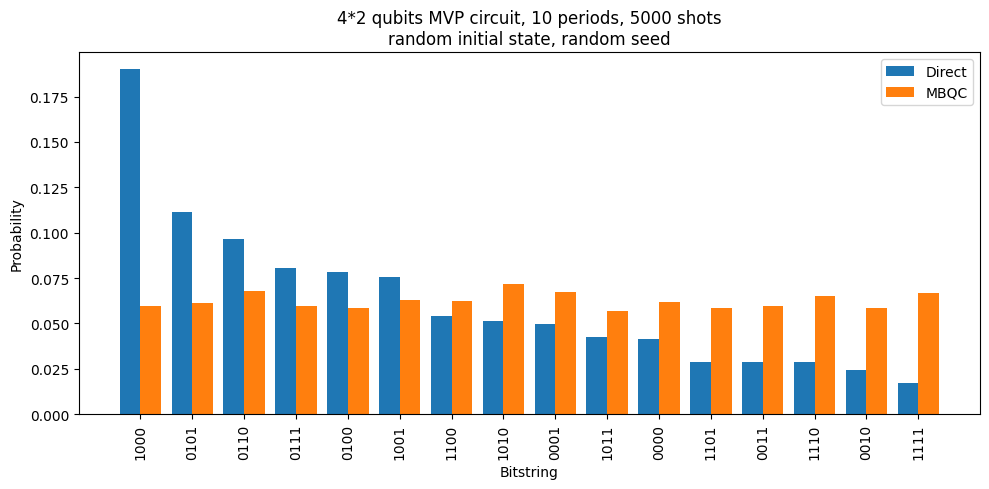

In [43]:
# backend + sampler
backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
sampler = Sampler(backend)

N = 4
periods = 10
shots = 5000

p1 = 0.1
p2 = 0.1
p_a = 0.1

backend = get_simulator(N, p_a)
pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
sampler = Sampler(backend)

seed = np.random.randint(1000)
psi = random_statevector(2**N)

# --- direct circuit ---
qc1 = QuantumCircuit(N)

data_qubits = list(range(N))
qc1.initialize(psi.data, data_qubits)
qc1 = MVP_gate(qc1, N, periods, seed)

creg1 = ClassicalRegister(N, "data")
qc1.add_register(creg1)

for j, q in enumerate(data_qubits):
    qc1.measure(q, creg1[j])


# --- MBQC circuit ---
qc2 = QuantumCircuit(2*N)
data_qubits = [2 * i for i in range(N)]
qc2.initialize(psi.data, data_qubits)
qc2 = MVP_MBQC(qc2, N, periods, seed, p1, p2)

creg2 = ClassicalRegister(N, "data")
qc2.add_register(creg2)

for j, q in enumerate(data_qubits):
    qc2.measure(q, creg2[j])


# --- transpile ---
t_qc1 = pm.run(qc1)
t_qc2 = pm.run(qc2)

# --- run sampler ---
job = sampler.run([t_qc1, t_qc2], shots=shots)
results = job.result()

# --- extract counts ---
counts1 = results[0].data.data.get_counts()
counts2 = results[1].data.data.get_counts()

# --- normalize ---
def normalize(counts, shots):
    return {k: v / shots for k, v in counts.items()}

probs1 = normalize(counts1, shots)
probs2 = normalize(counts2, shots)

# --- align keys ---
all_keys = list(set(probs1.keys()) | set(probs2.keys()))

# sort by descending probability (use probs1 as reference)
all_keys_sorted = sorted(all_keys, key=lambda k: probs1.get(k, 0), reverse=True)

vals1 = [probs1.get(k, 0) for k in all_keys_sorted]
vals2 = [probs2.get(k, 0) for k in all_keys_sorted]

x = np.arange(len(all_keys_sorted))
width = 0.4

# --- plot ---
plt.figure(figsize=(10, 5))

plt.bar(x - width/2, vals1, width, label="Direct")
plt.bar(x + width/2, vals2, width, label="MBQC")

plt.xticks(x, all_keys_sorted, rotation=90)
plt.xlabel("Bitstring")
plt.ylabel("Probability")

plt.title(
    f"{N}*2 qubits MVP circuit, {periods} periods, {shots} shots\n"
    f"random initial state, random seed"
)

plt.legend()
plt.tight_layout()
plt.show()